In [1]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedGroupKFold, cross_validate, cross_val_predict,
)
from sklearn.metrics import (make_scorer, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             classification_report, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from seq_utils import sequence_similarity_groups

In [2]:
# -------------------------------------------------------------------
# Load base feature table + merge in feature groups not yet assembled
# into feat_table_500ns.xlsx (Part C)
# -------------------------------------------------------------------
FEAT_TABLE_PATH = ("/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/"
                    "Shirts Lab/LCA_boltz_models/feat_table_500ns.xlsx")
path = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"

# Pocket residues carried forward as the active D/W / R-score feature set
# (Gate 84-90, Latch 114-118 residues are included per CLAUDE.md region defs)
POCKET_RESIDUES = [58, 59, 62, 83, 87, 88, 89, 92, 110, 115, 116, 117,
                    120, 122, 159, 160, 163, 164]

df = pd.read_excel(FEAT_TABLE_PATH, sheet_name="all_feats_500ns")
n_base = len(df)
print(f"Base cohort (all_feats_500ns): {n_base} sequences")

# ── Gate-latch RMSD-to-reference — already assembled as its own sheet ─────────
# (captures gate/latch *dynamics* relative to each sequence's own predicted
# structure; the static "Gate mean/SD" distance feature misses this)
gl_cols = ["Gate RMSD mean (A)", "Gate RMSD SD (A)", "Gate drift100 (A)", "Gate slope (A/ns)",
           "Latch RMSD mean (A)", "Latch RMSD SD (A)", "Latch drift100 (A)", "Latch slope (A/ns)"]
gl = pd.read_excel(FEAT_TABLE_PATH, sheet_name="gate_latch_rmsd_to_ref_500ns")
gl = gl.rename(columns={"Sequence": "seq_id"})[["seq_id"] + gl_cols]
df = df.merge(gl, left_on="name", right_on="seq_id", how="left").drop(columns=["seq_id"])
print(f"  + gate-latch RMSD-to-ref : {df[gl_cols[0]].notna().sum()}/{n_base} matched")

# ── Pocket volume — repo CSV, coverage gap for nonb_*/bind_* naming batches. ──
# Median-impute + explicit missingness flag so a batch effect (if the
# missingness pattern correlates with label) shows up in feature importance
# instead of being silently smeared into the imputed value.
pv_cols = ["pocket_vol_mean", "pocket_vol_std", "pocket_vol_closed_frac"]
pkt = pd.read_csv("pkt_vol/pocket_volume_features.csv")[["seq_id"] + pv_cols]
df = df.merge(pkt, left_on="name", right_on="seq_id", how="left").drop(columns=["seq_id"])
df["pocket_vol_missing"] = df["pocket_vol_mean"].isna().astype(int)
n_pv_missing = int(df["pocket_vol_missing"].sum())
print(f"  + pocket volume          : {n_base - n_pv_missing}/{n_base} matched "
      f"({n_pv_missing} missing -> median-imputed, flagged via pocket_vol_missing)")
for c in pv_cols:
    df[c] = df[c].fillna(df[c].median())
pv_cols = pv_cols + ["pocket_vol_missing"]

# ── Salt bridges — new aggregation, generate on Alpine first if missing ──────
# (python salt_bridge/aggregate_salt_bridge_feats.py --config config.yaml
#  --seq_list seq_ids.txt --out_csv salt_bridge/saltbridge_features_all_seqs.csv)
sb_cols = ["max_saltbridge_occupancy_pct", "n_saltbridges_gt50pct", "mean_top3_occupancy_pct"]
sb_path = "salt_bridge/saltbridge_features_all_seqs.csv"
if os.path.exists(sb_path):
    sb = pd.read_csv(sb_path)[["seq_id"] + sb_cols]
    df = df.merge(sb, left_on="name", right_on="seq_id", how="left").drop(columns=["seq_id"])
    print(f"  + salt bridges           : {df[sb_cols[0]].notna().sum()}/{n_base} matched")
    for c in sb_cols:
        df[c] = df[c].fillna(0.0)
else:
    print(f"  + salt bridges           : SKIPPED, {sb_path} not found "
          f"(run salt_bridge/aggregate_salt_bridge_feats.py on Alpine first)")
    for c in sb_cols:
        df[c] = 0.0

# ── Core vs. tail ligand-region R-score delta ─────────────────────────────────
# Directional signal: does this residue prefer contacting the steroid core or
# the carboxylate tail? Compact (18 cols) vs. merging all 72 raw core+tail D/W
# columns, which would fight Part B's goal of not letting any one family dominate.
core = pd.read_csv("water_analysis/agg_out/r_scores_all_sequences_40_500ns_core.csv")
tail = pd.read_csv("water_analysis/agg_out/r_scores_all_sequences_40_500ns_tail.csv")
core_sub = core[["seq_id"] + [f"R_{r}" for r in POCKET_RESIDUES]] \
    .rename(columns={f"R_{r}": f"R_{r}_core" for r in POCKET_RESIDUES})
tail_sub = tail[["seq_id"] + [f"R_{r}" for r in POCKET_RESIDUES]] \
    .rename(columns={f"R_{r}": f"R_{r}_tail" for r in POCKET_RESIDUES})
ct = core_sub.merge(tail_sub, on="seq_id", how="inner")
ct_cols = []
for r in POCKET_RESIDUES:
    col = f"delta_R_{r}"
    ct[col] = ct[f"R_{r}_core"] - ct[f"R_{r}_tail"]
    ct_cols.append(col)
df = df.merge(ct[["seq_id"] + ct_cols], left_on="name", right_on="seq_id", how="left").drop(columns=["seq_id"])
print(f"  + core/tail R delta      : {df[ct_cols[0]].notna().sum()}/{n_base} matched "
      f"(NaN = no contact in one/both sub-regions -> filled 0.0)")
for c in ct_cols:
    df[c] = df[c].fillna(0.0)

print(f"\nFinal merged table: {df.shape[0]} sequences x {df.shape[1]} columns")

# -------------------------------------------------------------------
# Feature groups (Part B): each family is selected independently downstream
# so no single family can dominate purely by column count or internal
# correlation. dw_pocket alone is 36/62 = 58% of candidates pre-selection,
# down from 36/48 = 75% in the previous feature set.
# -------------------------------------------------------------------
dw_cols = []
for r in POCKET_RESIDUES:
    dw_cols += [f"D_{r}", f"W_{r}"]

FEATURE_GROUP_COLS = {
    "gate_distance":    ["Gate mean (A)", "Gate SD (A)"],
    "dw_pocket":        dw_cols,
    "contact_type":     ["mean_n_polar", "std_n_polar", "mean_n_pos_charged",
                          "std_n_pos_charged", "mean_n_neg_charged", "std_n_neg_charged"],
    "rmsf":             ["Y23 RMSF (A)", "R79 RMSF (A)", "I110 RMSF (A)", "G163 RMSF (A)"],
    "gate_latch_rmsd":  gl_cols,
    "pocket_volume":    pv_cols,
    "salt_bridge":      sb_cols,
    "core_tail_delta":  ct_cols,
}

feature_cols = [c for cols in FEATURE_GROUP_COLS.values() for c in cols]
print(f"\nTotal candidate features: {len(feature_cols)}")
for gname, cols in FEATURE_GROUP_COLS.items():
    print(f"  {gname:<16}: {len(cols)}")


Base cohort (all_feats_500ns): 127 sequences
  + gate-latch RMSD-to-ref : 127/127 matched
  + pocket volume          : 62/127 matched (65 missing -> median-imputed, flagged via pocket_vol_missing)
  + salt bridges           : SKIPPED, salt_bridge/saltbridge_features_all_seqs.csv not found (run salt_bridge/aggregate_salt_bridge_feats.py on Alpine first)
  + core/tail R delta      : 123/127 matched (NaN = no contact in one/both sub-regions -> filled 0.0)

Final merged table: 127 sequences x 275 columns

Total candidate features: 81
  gate_distance   : 2
  dw_pocket       : 36
  contact_type    : 6
  rmsf            : 4
  gate_latch_rmsd : 8
  pocket_volume   : 4
  salt_bridge     : 3
  core_tail_delta : 18


/var/folders/b1/77x_k7v964g1hhhp9pz24yr40000gn/T/ipykernel_75950/1370165418.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pocket_vol_missing"] = df["pocket_vol_mean"].isna().astype(int)
/var/folders/b1/77x_k7v964g1hhhp9pz24yr40000gn/T/ipykernel_75950/1370165418.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c] = 0.0


In [3]:
# -------------------------------------------------------------------
# GroupAwareSelector (Part B): fold-safe transformer that
#   1. prunes within-group collinearity by hierarchically clustering
#      |Spearman correlation| and keeping the best-separating
#      representative per cluster (dw_pocket only, per CORR_PRUNE_GROUPS)
#   2. caps every family at its top-k features by univariate separation
#      score, so D/W pocket contacts can't dominate purely by column count
# Must be refit inside every CV fold (via the sklearn Pipeline below) so
# neither step leaks test-fold information into training.
# -------------------------------------------------------------------
def _feature_score(x_col, y):
    """|AUC - 0.5| of a single feature vs y; for >2 classes, best one-vs-rest AUC."""
    classes = np.unique(y)
    if len(classes) <= 2:
        y_bin = (y == classes[-1]).astype(int)
        if y_bin.sum() in (0, len(y_bin)):
            return 0.0
        return abs(roc_auc_score(y_bin, x_col) - 0.5)
    best = 0.0
    for c in classes:
        y_bin = (y == c).astype(int)
        if y_bin.sum() in (0, len(y_bin)):
            continue
        best = max(best, abs(roc_auc_score(y_bin, x_col) - 0.5))
    return best


class GroupAwareSelector(BaseEstimator, TransformerMixin):
    """
    groups            : {group_name: [column indices into X]}
    corr_prune_groups : group names to cluster-prune by |Spearman r| before budgeting
    k_per_group       : {group_name: k or None} cap after pruning
    corr_threshold    : |corr| above this -> same cluster (one representative kept)
    """
    def __init__(self, groups, corr_prune_groups=frozenset(), k_per_group=None,
                 corr_threshold=0.8):
        self.groups = groups
        self.corr_prune_groups = corr_prune_groups
        self.k_per_group = k_per_group or {}
        self.corr_threshold = corr_threshold

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        selected = []
        self.group_report_ = {}

        for gname, idx in self.groups.items():
            idx = np.array(idx)
            variances = X[:, idx].var(axis=0)
            valid = idx[variances > 1e-12]
            if len(valid) == 0:
                self.group_report_[gname] = {"input": len(idx), "after_corr": 0, "kept": 0}
                continue

            if gname in self.corr_prune_groups and len(valid) > 1:
                Xg = X[:, valid]
                corr, _ = spearmanr(Xg)
                corr = np.atleast_2d(corr)
                if corr.shape[0] == 1:   # spearmanr collapses to scalar for exactly 2 cols
                    corr = np.array([[1.0, corr.item()], [corr.item(), 1.0]])
                dist = 1.0 - np.abs(np.nan_to_num(corr, nan=0.0))
                np.fill_diagonal(dist, 0.0)
                dist = (dist + dist.T) / 2   # enforce symmetry against fp noise
                Z = linkage(squareform(dist, checks=False), method="average")
                cluster_ids = fcluster(Z, t=(1 - self.corr_threshold), criterion="distance")
                reps = []
                for cid in np.unique(cluster_ids):
                    members = valid[cluster_ids == cid]
                    scores = [_feature_score(X[:, m], y) for m in members]
                    reps.append(members[int(np.argmax(scores))])
                pruned = np.array(reps)
            else:
                pruned = valid

            k = self.k_per_group.get(gname)
            if k is not None and len(pruned) > k:
                scores = np.array([_feature_score(X[:, m], y) for m in pruned])
                top_k = pruned[np.argsort(scores)[-k:]]
            else:
                top_k = pruned

            self.group_report_[gname] = {
                "input": len(idx), "after_corr": len(pruned), "kept": len(top_k)
            }
            selected.extend(top_k.tolist())

        self.selected_indices_ = np.array(sorted(selected))
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.selected_indices_]


# ── Map feature groups to column indices within feature_cols ──────────────────
col_index = {c: i for i, c in enumerate(feature_cols)}
FEATURE_GROUPS = {g: [col_index[c] for c in cols] for g, cols in FEATURE_GROUP_COLS.items()}

CORR_PRUNE_GROUPS = {"dw_pocket"}                       # Part B.1: collinearity pruning
K_PER_GROUP = {"dw_pocket": 12, "core_tail_delta": 8}   # Part B.2: per-family budget


# -------------------------------------------------------------------
# grouped_permutation_test (Part A.4 correction): sklearn's own
# permutation_test_score(..., groups=...) only shuffles y WITHIN each group,
# which is close to a no-op here -- 66 of 94 sequence-similarity groups are
# singletons, so most labels aren't actually perturbed by a "permutation."
# That understates significance (contaminated null distribution). This
# instead shuffles y completely freely each permutation while still using
# `groups` for fold-safe CV splitting on every permuted run, which is the
# valid test of "could this grouped-CV score arise by chance."
# -------------------------------------------------------------------
def grouped_permutation_test(estimator, X, y, groups, cv, scoring="balanced_accuracy",
                              n_permutations=100, random_state=None):
    rng = np.random.default_rng(random_state)

    observed = cross_validate(estimator, X, y, cv=cv, groups=groups,
                               scoring=scoring)["test_score"].mean()

    perm_scores = np.empty(n_permutations)
    for i in range(n_permutations):
        y_perm = rng.permutation(y)
        perm_scores[i] = cross_validate(estimator, X, y_perm, cv=cv, groups=groups,
                                         scoring=scoring)["test_score"].mean()

    pval = (1 + np.sum(perm_scores >= observed)) / (1 + n_permutations)
    return observed, perm_scores, pval


Total samples: 127  |  Binders: 53  |  Nonbinders: 74
Candidate features: 81

Per-group selection (full-dataset fit, descriptive only):
  gate_distance   :   2 -> after corr-prune   2 -> kept   2
  dw_pocket       :  36 -> after corr-prune  35 -> kept  12
  contact_type    :   6 -> after corr-prune   6 -> kept   6
  rmsf            :   4 -> after corr-prune   4 -> kept   4
  gate_latch_rmsd :   8 -> after corr-prune   8 -> kept   8
  pocket_volume   :   4 -> after corr-prune   4 -> kept   4
  salt_bridge     :   3 -> after corr-prune   0 -> kept   0
  core_tail_delta :  18 -> after corr-prune  18 -> kept   8

Total features kept (descriptive): 44 of 81


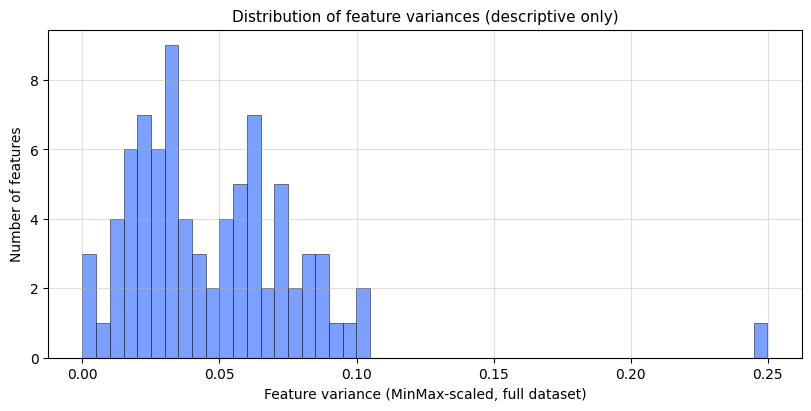

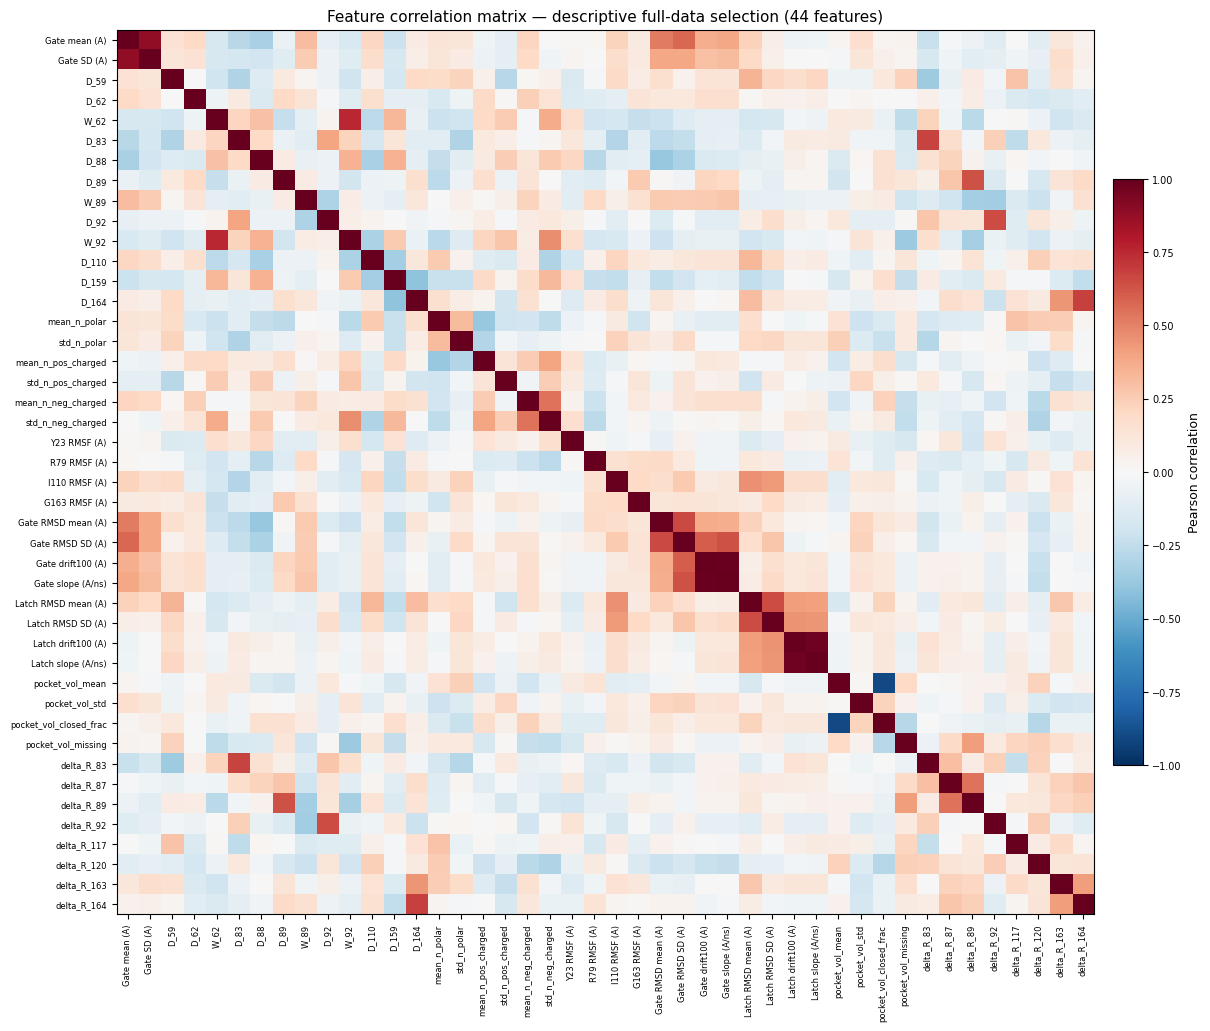


Sequence-similarity groups (>=95% identity on variable positions): 94 groups from 127 sequences
  Largest group size: 3  |  Singleton groups: 66


In [4]:
# -------------------------------------------------------------------
# Exploratory diagnostics only (Part A.1): descriptive variance and
# correlation view, fit ONCE on the full dataset purely for visualization.
# This is NOT what the CV pipeline below uses -- the CV pipeline refits
# scaling and GroupAwareSelector inside every fold (next section), so
# nothing here leaks into the reported CV metrics.
# -------------------------------------------------------------------
X_all = df[feature_cols].values
y = df["Label"].values

n_binders    = y.sum()
n_nonbinders = (y == 0).sum()
print(f"Total samples: {len(y)}  |  Binders: {n_binders}  |  Nonbinders: {n_nonbinders}")
print(f"Candidate features: {len(feature_cols)}")

scaler_diag  = MinMaxScaler()
X_all_scaled = scaler_diag.fit_transform(X_all)

diag_selector = GroupAwareSelector(groups=FEATURE_GROUPS, corr_prune_groups=CORR_PRUNE_GROUPS,
                                    k_per_group=K_PER_GROUP)
diag_selector.fit(X_all_scaled, y)

print("\nPer-group selection (full-dataset fit, descriptive only):")
for gname, rep in diag_selector.group_report_.items():
    print(f"  {gname:<16}: {rep['input']:>3} -> after corr-prune {rep['after_corr']:>3} -> kept {rep['kept']:>3}")
print(f"\nTotal features kept (descriptive): {len(diag_selector.selected_indices_)} of {len(feature_cols)}")

# ── Variance summary (descriptive) ─────────────────────────────────────────
variances = pd.Series(X_all_scaled.var(axis=0), index=feature_cols)
fig_var, ax_var = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax_var.hist(variances, bins=50, color='#648FFF', edgecolor='k', linewidth=0.4, alpha=0.85)
ax_var.set_xlabel('Feature variance (MinMax-scaled, full dataset)', fontsize=10)
ax_var.set_ylabel('Number of features', fontsize=10)
ax_var.set_title('Distribution of feature variances (descriptive only)', fontsize=11)
ax_var.grid(True, alpha=0.4)
plt.show()

# ── Correlation matrix on the descriptively-selected features ─────────────────
sel_cols_diag = [feature_cols[i] for i in diag_selector.selected_indices_]
X_filt_df   = pd.DataFrame(X_all_scaled[:, diag_selector.selected_indices_], columns=sel_cols_diag)
corr_matrix = X_filt_df.corr()

n  = len(sel_cols_diag)
fs = max(12, n * 0.18)

fig, ax = plt.subplots(figsize=(fs, fs * 0.85), constrained_layout=True)
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(sel_cols_diag, rotation=90, fontsize=max(4, 7 - n // 40))
ax.set_yticklabels(sel_cols_diag, fontsize=max(4, 7 - n // 40))
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Pearson correlation', fontsize=9)
cbar.ax.tick_params(labelsize=7)
ax.set_title(f'Feature correlation matrix — descriptive full-data selection ({n} features)', fontsize=11)
plt.show()

# ── Sequence-similarity CV groups (Part A.4) ───────────────────────────────
# Sequences >=95% identical on variable (designed) positions are assigned the
# same group id, so StratifiedGroupKFold below can't split near-identical
# designed variants across train/test.
sequences  = df["Sequence"].astype(str).str.strip().tolist()
seq_groups = sequence_similarity_groups(sequences, identity_threshold=0.95)
group_sizes = pd.Series(seq_groups).value_counts()
print(f"\nSequence-similarity groups (>=95% identity on variable positions): "
      f"{group_sizes.shape[0]} groups from {len(sequences)} sequences")
print(f"  Largest group size: {group_sizes.max()}  |  Singleton groups: {(group_sizes == 1).sum()}")

X = X_all   # unscaled, full feature matrix -- scaling happens inside the CV pipeline

## Binary Classficiation
Testing the Random Forest as a 2-class model: **Binder**, **Nonbinder**.

In [5]:
N_SPLITS = 7
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print(f"\n--- Fold composition (n_splits={N_SPLITS}, grouped by sequence similarity) ---")
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, seq_groups)):
    n_b_train  = y[train_idx].sum()
    n_b_test   = y[test_idx].sum()
    n_nb_train = (y[train_idx] == 0).sum()
    n_nb_test  = (y[test_idx]  == 0).sum()
    print(f"  Fold {fold+1}: train = {n_b_train} binders / {n_nb_train} nonbinders  |  "
          f"test = {n_b_test} binders / {n_nb_test} nonbinders")

pipe = Pipeline([
    ("scale",  MinMaxScaler()),
    ("select", GroupAwareSelector(groups=FEATURE_GROUPS, corr_prune_groups=CORR_PRUNE_GROUPS,
                                   k_per_group=K_PER_GROUP)),
    ("rf",     RandomForestClassifier(n_estimators=500, max_features="sqrt",
                                       class_weight="balanced", random_state=42)),
])

# -------------------------------------------------------------------
# Stratified GROUP cross-validation (Part A.1 + A.4): scaling and feature
# selection are refit inside every fold via the pipeline above, eliminating
# the previous full-dataset-fit leakage. StratifiedGroupKFold keeps
# near-identical sequence variants from splitting across train/test.
# -------------------------------------------------------------------
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc",
    "f1":                make_scorer(f1_score,        zero_division=0),
    "precision":         make_scorer(precision_score, zero_division=0),
    "recall":            make_scorer(recall_score,    zero_division=0),
}

cv_results = cross_validate(
    pipe, X, y, cv=cv, groups=seq_groups,
    scoring=scoring,
    return_train_score=False,
)

metrics = {k.replace("test_", ""): v for k, v in cv_results.items()
           if k.startswith("test_")}

print(f"\n--- {N_SPLITS}-fold grouped stratified CV (balanced RF, nested pipeline) ---")
metrics_df = pd.DataFrame({
    k: {"Mean": round(v.mean(), 3), "SD": round(v.std(), 3)}
    for k, v in metrics.items()
}).T
print(metrics_df.to_string())

# -------------------------------------------------------------------
# Permutation test (see grouped_permutation_test docstring above for why
# this replaces sklearn's built-in groups-aware shuffle)
# -------------------------------------------------------------------
score, perm_scores, pval = grouped_permutation_test(
    pipe, X, y, seq_groups, cv, scoring="balanced_accuracy",
    n_permutations=100, random_state=42,
)
print(f"\nPermutation test  |  Observed balanced accuracy: {score:.3f}  |  p-value: {pval:.3f}")

# -------------------------------------------------------------------
# Fit on full dataset for importance/interpretation only (disclosed as a
# full-data fit, not a generalization estimate -- see ROC curve title below)
# -------------------------------------------------------------------
pipe.fit(X, y)
rf = pipe.named_steps["rf"]
selected_idx  = pipe.named_steps["select"].selected_indices_
selected_cols = [feature_cols[i] for i in selected_idx]
print(f"\nFull-data fit selected {len(selected_cols)} features: {selected_cols}")

y_pred = pipe.predict(X)
y_prob = pipe.predict_proba(X)[:, 1]


--- Fold composition (n_splits=7, grouped by sequence similarity) ---
  Fold 1: train = 45 binders / 63 nonbinders  |  test = 8 binders / 11 nonbinders
  Fold 2: train = 45 binders / 63 nonbinders  |  test = 8 binders / 11 nonbinders
  Fold 3: train = 45 binders / 63 nonbinders  |  test = 8 binders / 11 nonbinders
  Fold 4: train = 45 binders / 63 nonbinders  |  test = 8 binders / 11 nonbinders
  Fold 5: train = 46 binders / 64 nonbinders  |  test = 7 binders / 10 nonbinders
  Fold 6: train = 46 binders / 64 nonbinders  |  test = 7 binders / 10 nonbinders
  Fold 7: train = 46 binders / 64 nonbinders  |  test = 7 binders / 10 nonbinders



--- 7-fold grouped stratified CV (balanced RF, nested pipeline) ---
                    Mean     SD
accuracy           0.797  0.065
balanced_accuracy  0.783  0.059
roc_auc            0.893  0.063
f1                 0.741  0.075
precision          0.827  0.135
recall             0.699  0.131



Permutation test  |  Observed balanced accuracy: 0.783  |  p-value: 0.010



Full-data fit selected 44 features: ['Gate mean (A)', 'Gate SD (A)', 'D_59', 'D_62', 'W_62', 'D_83', 'D_88', 'D_89', 'W_89', 'D_92', 'W_92', 'D_110', 'D_159', 'D_164', 'mean_n_polar', 'std_n_polar', 'mean_n_pos_charged', 'std_n_pos_charged', 'mean_n_neg_charged', 'std_n_neg_charged', 'Y23 RMSF (A)', 'R79 RMSF (A)', 'I110 RMSF (A)', 'G163 RMSF (A)', 'Gate RMSD mean (A)', 'Gate RMSD SD (A)', 'Gate drift100 (A)', 'Gate slope (A/ns)', 'Latch RMSD mean (A)', 'Latch RMSD SD (A)', 'Latch drift100 (A)', 'Latch slope (A/ns)', 'pocket_vol_mean', 'pocket_vol_std', 'pocket_vol_closed_frac', 'pocket_vol_missing', 'delta_R_83', 'delta_R_87', 'delta_R_89', 'delta_R_92', 'delta_R_117', 'delta_R_120', 'delta_R_163', 'delta_R_164']


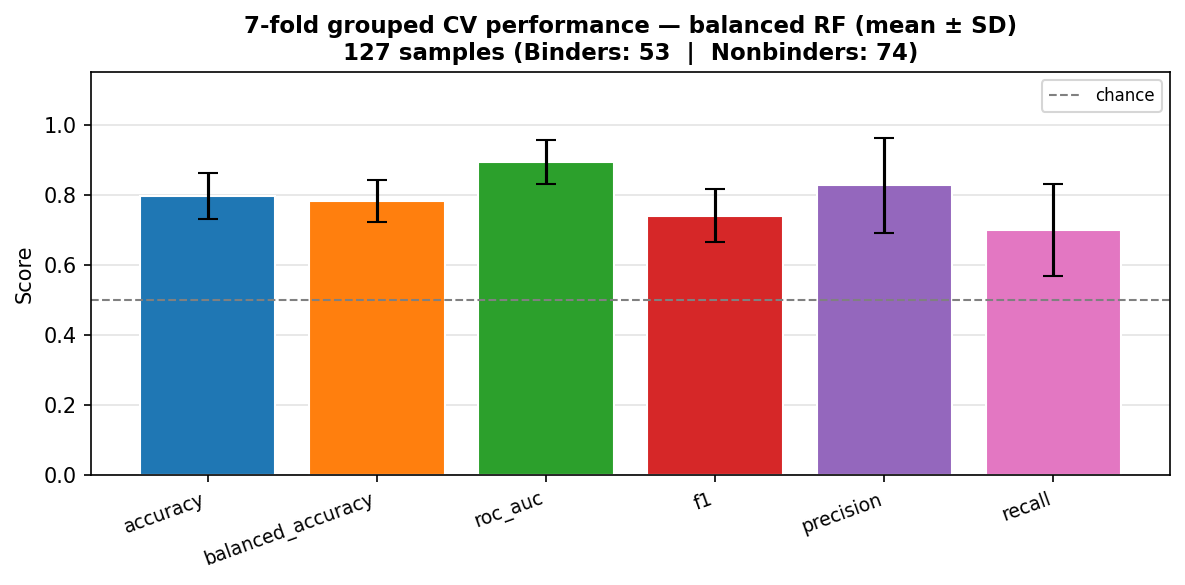

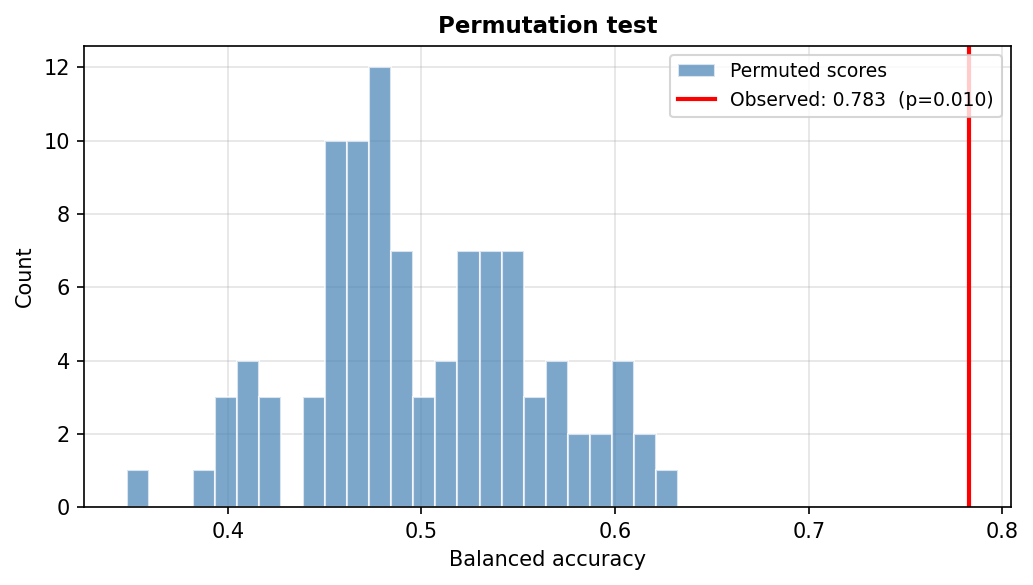

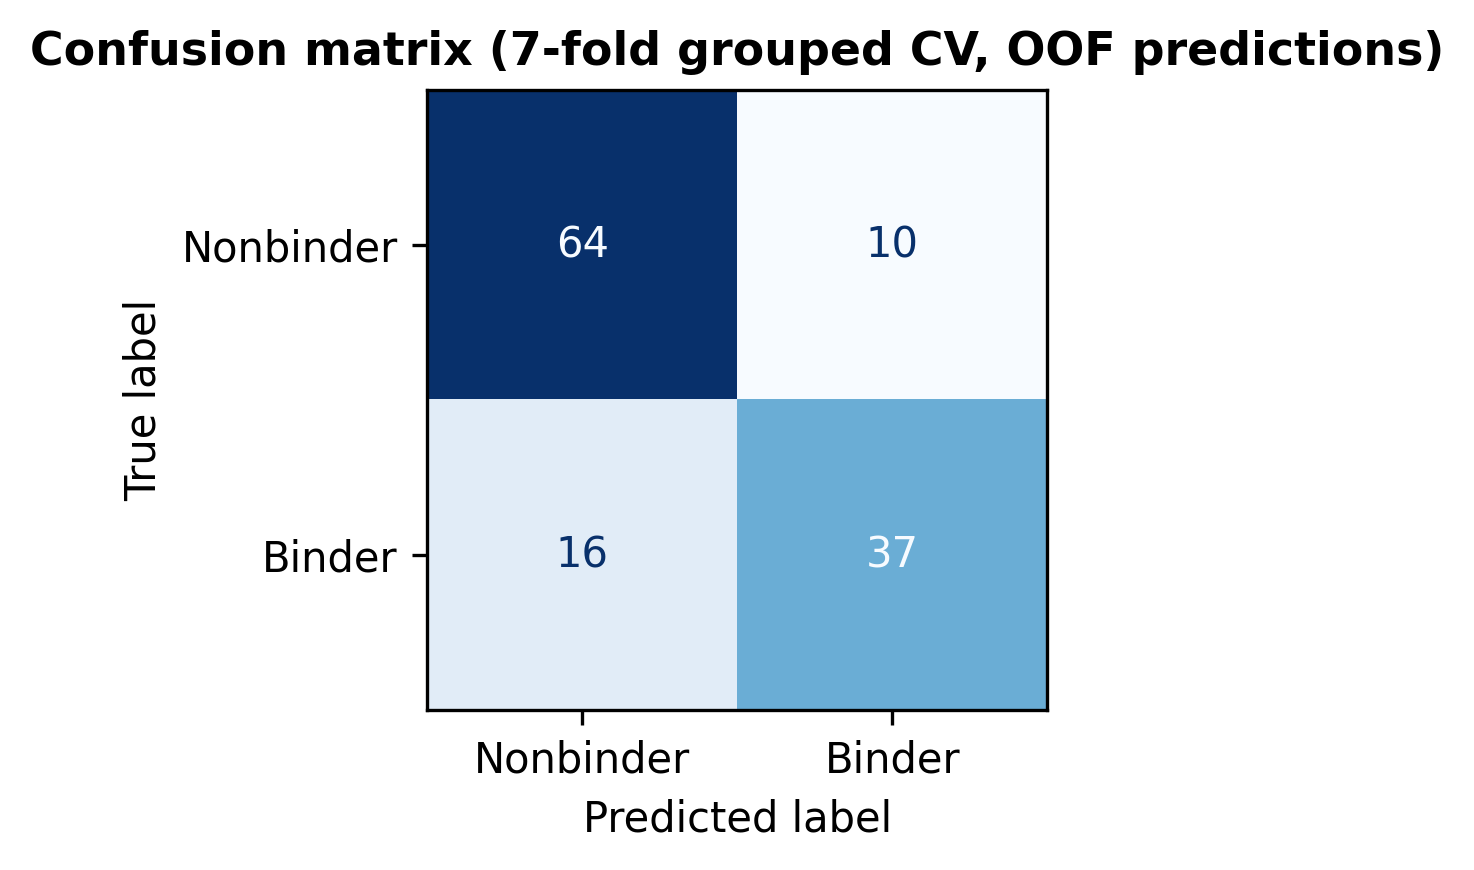

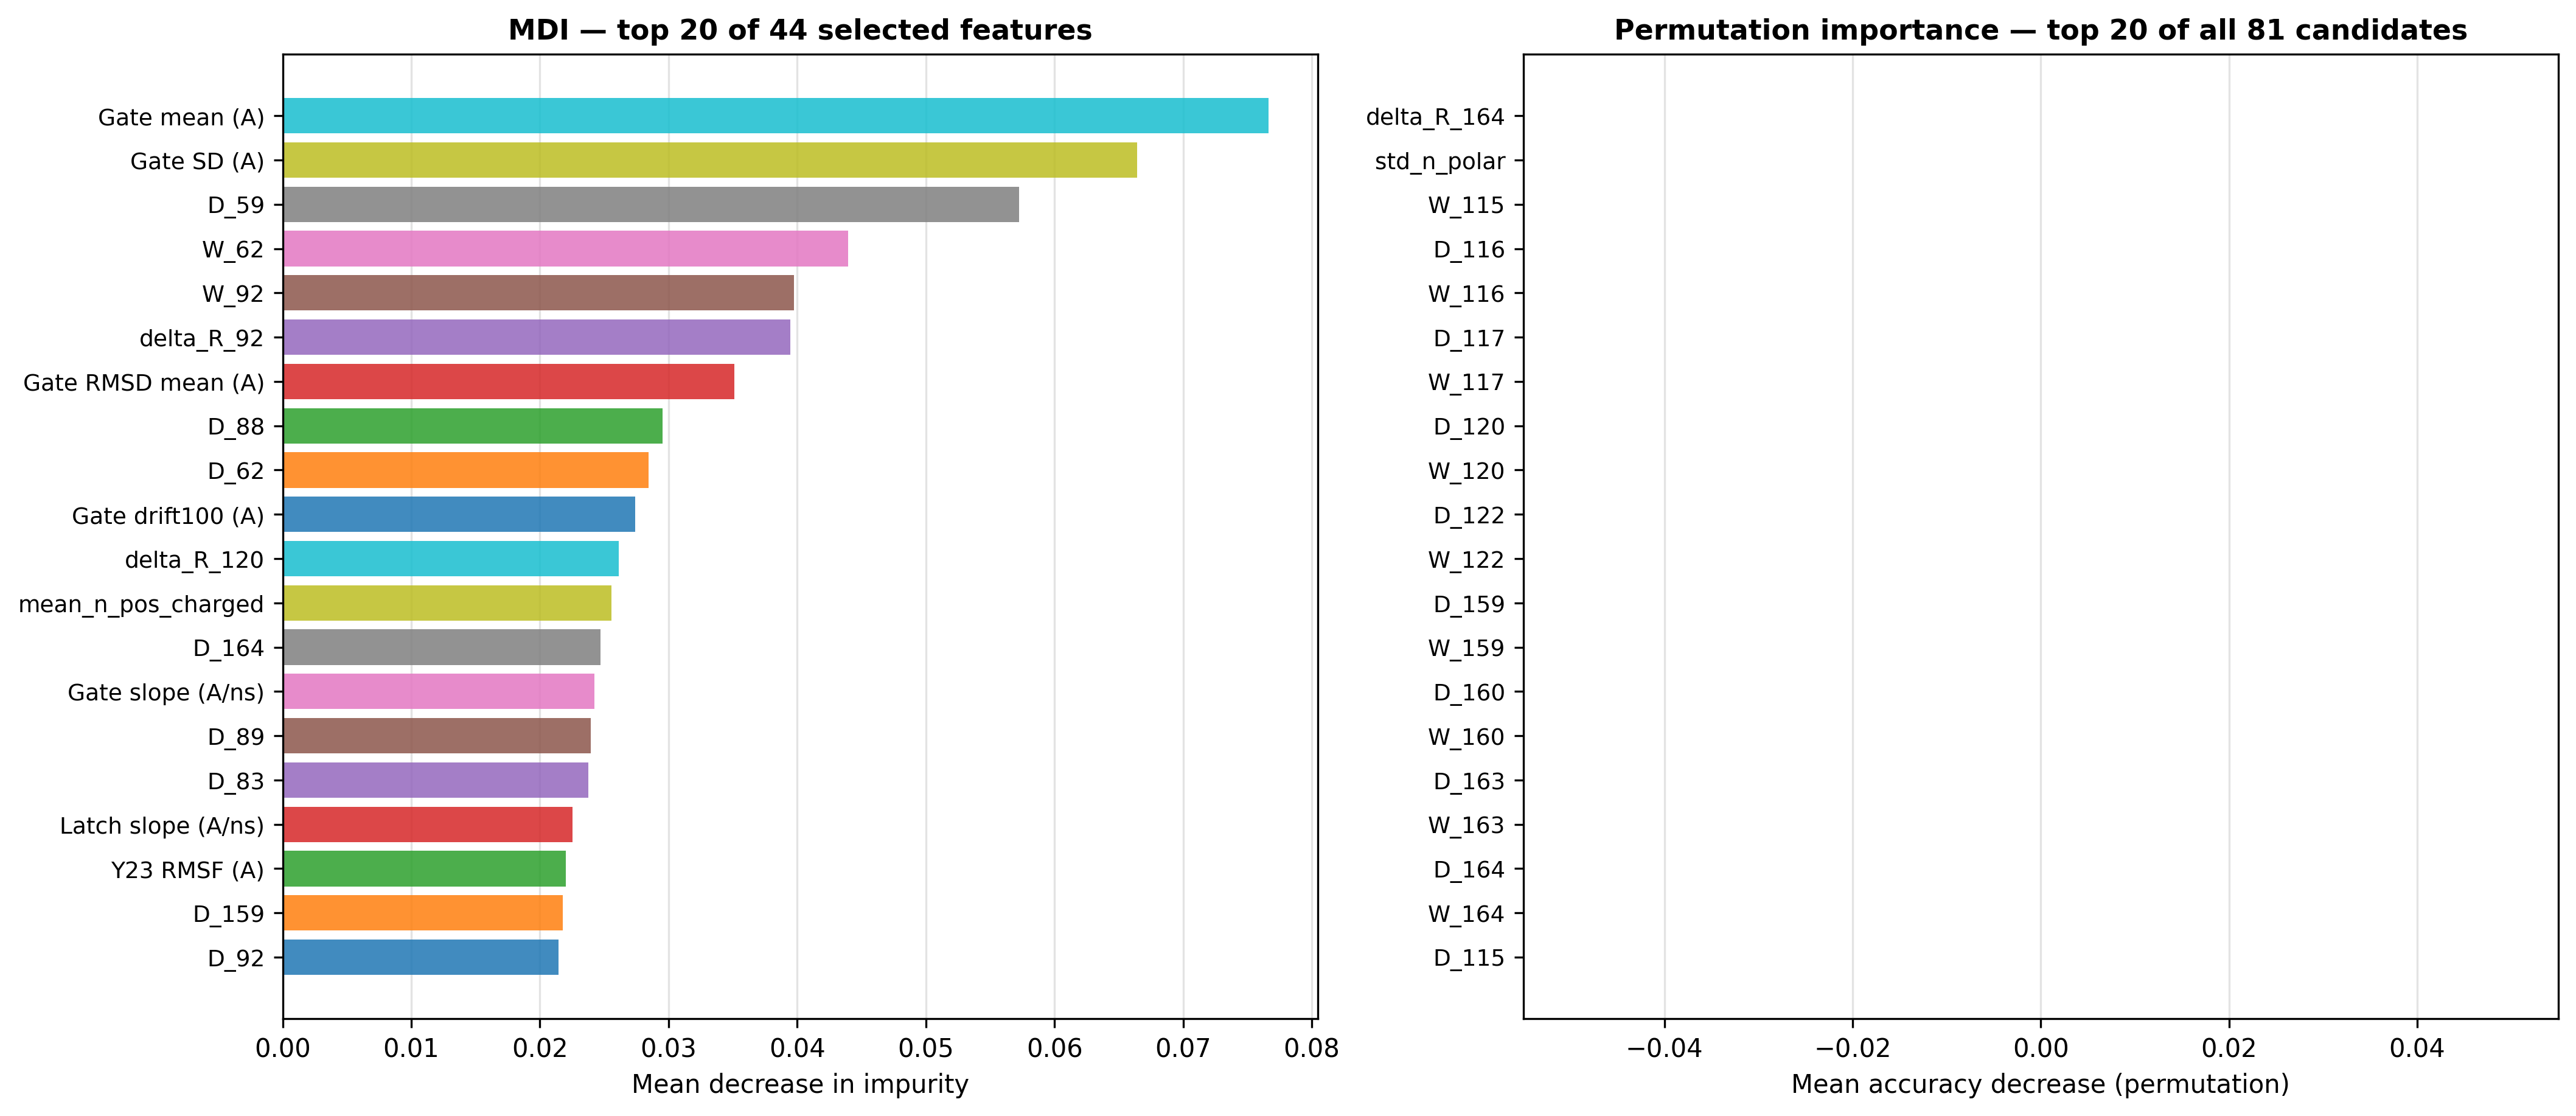

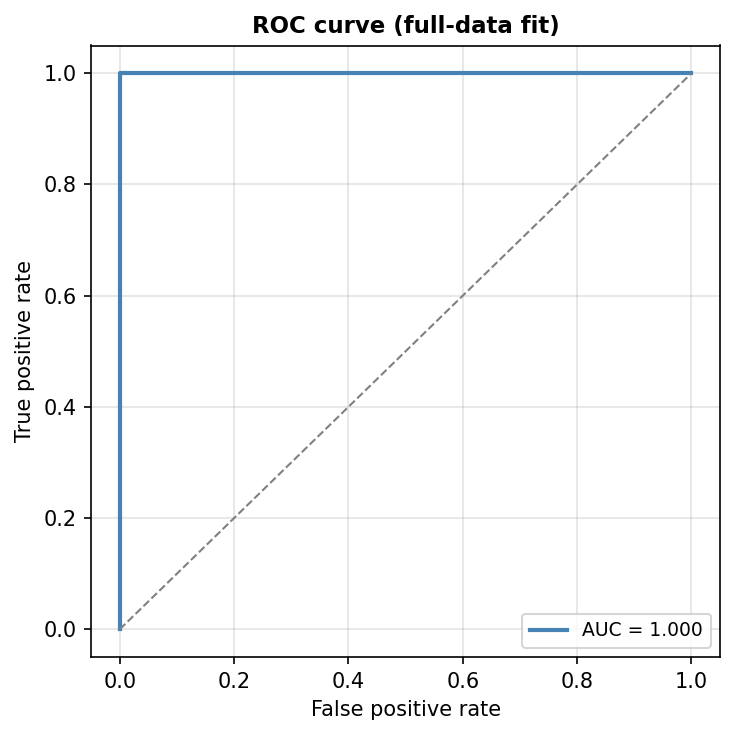


--- Classification report (7-fold grouped CV, OOF predictions) ---
              precision    recall  f1-score   support

   Nonbinder       0.80      0.86      0.83        74
      Binder       0.79      0.70      0.74        53

    accuracy                           0.80       127
   macro avg       0.79      0.78      0.79       127
weighted avg       0.79      0.80      0.79       127


--- Incorrectly predicted sequences (26 total) ---
             seq_id true_label predicted_label     error_type
       seq42_binder     Binder       Nonbinder False Negative
    bind_083_binder     Binder       Nonbinder False Negative
    bind_101_binder     Binder       Nonbinder False Negative
    bind_102_binder     Binder       Nonbinder False Negative
    bind_022_binder     Binder       Nonbinder False Negative
    bind_110_binder     Binder       Nonbinder False Negative
    bind_100_binder     Binder       Nonbinder False Negative
    bind_099_binder     Binder       Nonbinder False Nega

In [6]:
# -------------------------------------------------------------------
# Figure 1: CV metric summary
# -------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 4), dpi=150)
metric_names = list(metrics.keys())
means = [metrics[m].mean() for m in metric_names]
sds   = [metrics[m].std()  for m in metric_names]
x     = np.arange(len(metric_names))

ax1.bar(x, means, yerr=sds, capsize=5,
        color=plt.get_cmap("tab10")(np.linspace(0, 0.6, len(metric_names))),
        edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Score", fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.axhline(0.5, color="gray", linestyle="--", lw=1, label="chance")
ax1.set_title(f"{N_SPLITS}-fold grouped CV performance — balanced RF (mean ± SD)\n{len(y)} samples (Binders: {n_binders}  |  Nonbinders: {n_nonbinders})",
              fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(True, axis="y", alpha=0.35)
ax1.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 2: permutation test
# -------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(7, 4), dpi=150)
ax2.hist(perm_scores, bins=25, color="steelblue", alpha=0.7, edgecolor="white",
         label="Permuted scores")
ax2.axvline(score, color="red", lw=2, label=f"Observed: {score:.3f}  (p={pval:.3f})")
ax2.set_xlabel("Balanced accuracy", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.set_title("Permutation test", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.35)
ax2.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 3: confusion matrix (grouped CV, out-of-fold predictions)
# -------------------------------------------------------------------
y_pred_cv = cross_val_predict(pipe, X, y, cv=cv, groups=seq_groups)   # OOF predictions
fig3, ax3 = plt.subplots(figsize=(7, 3), dpi=300)
cm_mat = confusion_matrix(y, y_pred_cv)
disp   = ConfusionMatrixDisplay(cm_mat, display_labels=["Nonbinder", "Binder"])
disp.plot(ax=ax3, colorbar=False, cmap="Blues")
ax3.set_title(f"Confusion matrix ({N_SPLITS}-fold grouped CV, OOF predictions)", fontsize=11, fontweight="bold")
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 4: feature importances (Part A.2, A.3 -- corrected labels)
# MDI is computed on the RF, which only ever saw the post-selection
# `selected_cols` -- so MDI labels now come from that same list (previously
# they came from the original, longer, pre-selection feature_cols, which
# silently mislabeled every bar). Permutation importance runs the whole
# pipeline (scale -> select -> rf) against the FULL original feature_cols,
# so any feature the selector dropped correctly reads ~0 importance, and
# there's no name/length mismatch there either. This was already computed
# in earlier notebook versions but never plotted (dead code) -- it's shown
# here as a cross-check against MDI, since MDI is biased toward
# high-cardinality/correlated features and permutation importance is not.
# -------------------------------------------------------------------
mdi_imp  = rf.feature_importances_
perm_imp = permutation_importance(pipe, X, y, n_repeats=30, random_state=42, n_jobs=1)

TOP_N = 20

mdi_sorted_idx = np.argsort(mdi_imp)[-min(TOP_N, len(mdi_imp)):]
mdi_names      = [selected_cols[i] for i in mdi_sorted_idx]

perm_sorted_idx = np.argsort(perm_imp.importances_mean)[-TOP_N:]
perm_names      = [feature_cols[i] for i in perm_sorted_idx]

prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 6), dpi=300, constrained_layout=True)

colors_a = [prop_cycle[i % len(prop_cycle)] for i in range(len(mdi_sorted_idx))]
ax4a.barh(range(len(mdi_sorted_idx)), mdi_imp[mdi_sorted_idx], color=colors_a, alpha=0.85)
ax4a.set_yticks(range(len(mdi_sorted_idx)))
ax4a.set_yticklabels(mdi_names, fontsize=9)
ax4a.set_xlabel("Mean decrease in impurity", fontsize=10)
ax4a.set_title(f"MDI — top {len(mdi_sorted_idx)} of {len(selected_cols)} selected features",
               fontsize=11, fontweight="bold")
ax4a.grid(True, axis="x", alpha=0.35)
ax4a.set_axisbelow(True)

colors_b = [prop_cycle[i % len(prop_cycle)] for i in range(len(perm_sorted_idx))]
ax4b.barh(range(len(perm_sorted_idx)), perm_imp.importances_mean[perm_sorted_idx],
          xerr=perm_imp.importances_std[perm_sorted_idx], color=colors_b, alpha=0.85)
ax4b.set_yticks(range(len(perm_sorted_idx)))
ax4b.set_yticklabels(perm_names, fontsize=9)
ax4b.set_xlabel("Mean accuracy decrease (permutation)", fontsize=10)
ax4b.set_title(f"Permutation importance — top {TOP_N} of all {len(feature_cols)} candidates",
               fontsize=11, fontweight="bold")
ax4b.grid(True, axis="x", alpha=0.35)
ax4b.set_axisbelow(True)

# -------------------------------------------------------------------
# Figure 5: ROC curve
# -------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc      = auc(fpr, tpr)

fig5, ax5 = plt.subplots(figsize=(5, 5), dpi=150)
ax5.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {roc_auc:.3f}")
ax5.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax5.set_xlabel("False positive rate", fontsize=10)
ax5.set_ylabel("True positive rate", fontsize=10)
ax5.set_title("ROC curve (full-data fit)", fontsize=11, fontweight="bold")
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.35)
ax5.set_axisbelow(True)
plt.tight_layout()

plt.show()

# -------------------------------------------------------------------
# Classification report + incorrect predictions
# -------------------------------------------------------------------
seq_ids = df["name"].tolist()   # ← add this; assumes dataframe is named df

print(f"\n--- Classification report ({N_SPLITS}-fold grouped CV, OOF predictions) ---")
print(classification_report(y, y_pred_cv, target_names=["Nonbinder", "Binder"],
                             zero_division=0))

wrong_mask = y_pred_cv != y
wrong_df   = pd.DataFrame({
    "seq_id":          [seq_ids[i] for i in np.where(wrong_mask)[0]],
    "true_label":      ["Binder" if y[i] == 1 else "Nonbinder"
                        for i in np.where(wrong_mask)[0]],
    "predicted_label": ["Binder" if y_pred_cv[i] == 1 else "Nonbinder"
                        for i in np.where(wrong_mask)[0]],
    "error_type":      ["False Negative" if y[i] == 1 else "False Positive"
                        for i in np.where(wrong_mask)[0]],
}).sort_values("error_type").reset_index(drop=True)

print(f"\n--- Incorrectly predicted sequences ({len(wrong_df)} total) ---")
print(wrong_df.to_string(index=False))

fn = wrong_df[wrong_df["error_type"] == "False Negative"]
fp = wrong_df[wrong_df["error_type"] == "False Positive"]
print(f"\n  False Negatives (binders predicted as nonbinder): {len(fn)}")
for _, row in fn.iterrows():
    print(f"    {row['seq_id']}")
print(f"\n  False Positives (nonbinders predicted as binder): {len(fp)}")
for _, row in fp.iterrows():
    print(f"    {row['seq_id']}")

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig1.savefig(os.path.join(path, "ML", f"filt_RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")
fig3.savefig(os.path.join(path, "ML", f"filt_RF_confusion_matrix_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")
fig4.savefig(os.path.join(path, "ML", f"filt_RF_feat_importance_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")

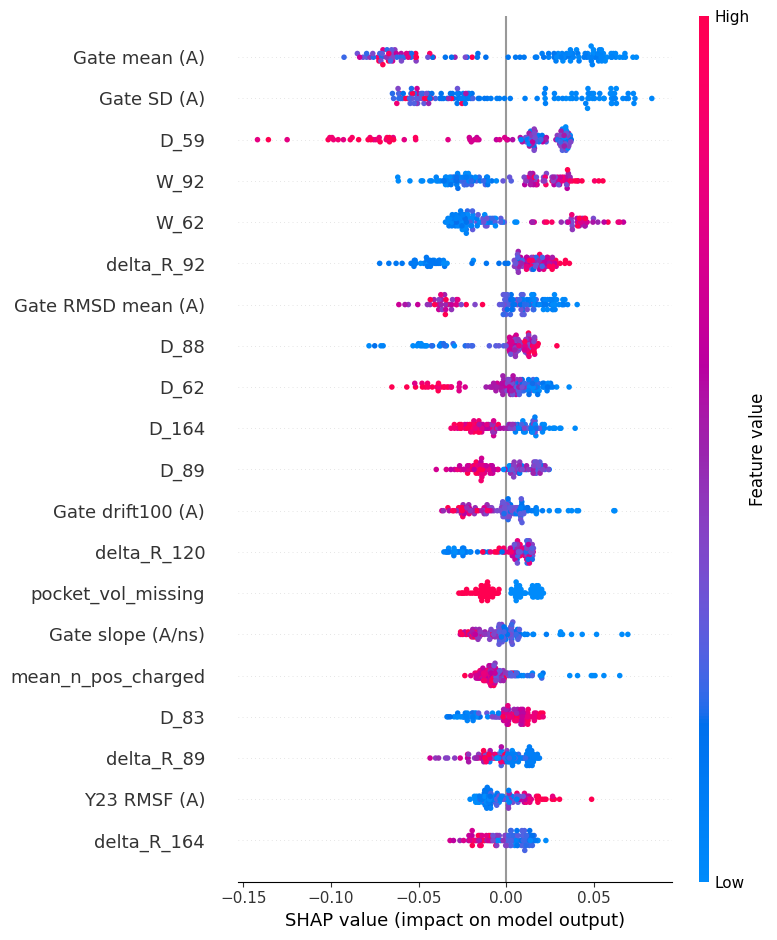

In [7]:
# -------------------------------------------------------------------
# SHAP summary (Part A.2 -- corrected feature names)
# X_selected is scale+select transformed, i.e. exactly what `rf` was
# trained on, so feature_names=selected_cols now lines up column-for-column
# (previously this used the original, pre-selection feature_cols).
# -------------------------------------------------------------------
X_selected = pipe[:-1].transform(X)   # scale -> select, same columns rf saw

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_selected)

sv = shap_values[:, :, 1]

shap.summary_plot(sv, X_selected, feature_names=selected_cols, max_display=20, show=False)

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
plt.savefig(os.path.join(path, "ML", f"filtered_DW_RF_shap_summary_{len(y)}samples.png"), dpi=300, bbox_inches='tight')
plt.show()

## Multiclass Classification
Testing the Random Forest as a 4-class model: **Binder**, **False Positive**, **Low Confidence**, **Fail Geometry**.

In [8]:
# -------------------------------------------------------------------
# Multiclass labels
# Adjust column name below if your sheet uses a different header
# -------------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, classification_report, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_predict

GROUP_COL = "Group"  # <-- change if needed

le = LabelEncoder()
y_mc = le.fit_transform(df[GROUP_COL].values)
class_names = le.classes_

print("Classes:", list(class_names))
print("Class distribution:")
for cls, encoded in zip(class_names, range(len(class_names))):
    print(f"  {cls}: {(y_mc == encoded).sum()}")
print(f"  Total: {len(y_mc)}")


Classes: ['binder', 'fail_gate', 'low_pkt', 'nonbinder']
Class distribution:
  binder: 53
  fail_gate: 10
  low_pkt: 9
  nonbinder: 55
  Total: 127


In [9]:
# -------------------------------------------------------------------
# Multiclass RF + grouped stratified CV (nested pipeline; Parts A/B applied
# identically to the binary model above -- same sequence-similarity groups,
# same GroupAwareSelector config)
# -------------------------------------------------------------------
from sklearn.metrics import make_scorer

pipe_mc = Pipeline([
    ("scale",  MinMaxScaler()),
    ("select", GroupAwareSelector(groups=FEATURE_GROUPS, corr_prune_groups=CORR_PRUNE_GROUPS,
                                   k_per_group=K_PER_GROUP)),
    ("rf",     RandomForestClassifier(n_estimators=500, max_features="sqrt",
                                       class_weight="balanced", random_state=42)),
])

scoring_mc = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc_ovr",          # one-vs-rest, uses predict_proba
    "f1":                make_scorer(f1_score,        average="macro", zero_division=0),
    "precision":         make_scorer(precision_score, average="macro", zero_division=0),
    "recall":            make_scorer(recall_score,    average="macro", zero_division=0),
}

cv_mc = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

cv_mc_results = cross_validate(
    pipe_mc, X, y_mc, cv=cv_mc, groups=seq_groups,
    scoring=scoring_mc,
    return_train_score=False,
)

metrics_mc = {k.replace("test_", ""): v for k, v in cv_mc_results.items()
              if k.startswith("test_")}

print(f"--- {N_SPLITS}-fold grouped stratified CV (multiclass, balanced RF, nested pipeline) ---")
mc_df = pd.DataFrame({
    k: {"Mean": round(v.mean(), 3), "SD": round(v.std(), 3)}
    for k, v in metrics_mc.items()
}).T
print(mc_df.to_string())


--- 7-fold grouped stratified CV (multiclass, balanced RF, nested pipeline) ---
                    Mean     SD
accuracy           0.772  0.068
balanced_accuracy  0.675  0.140
roc_auc            0.935  0.022
f1                 0.653  0.168
precision          0.680  0.208
recall             0.675  0.140


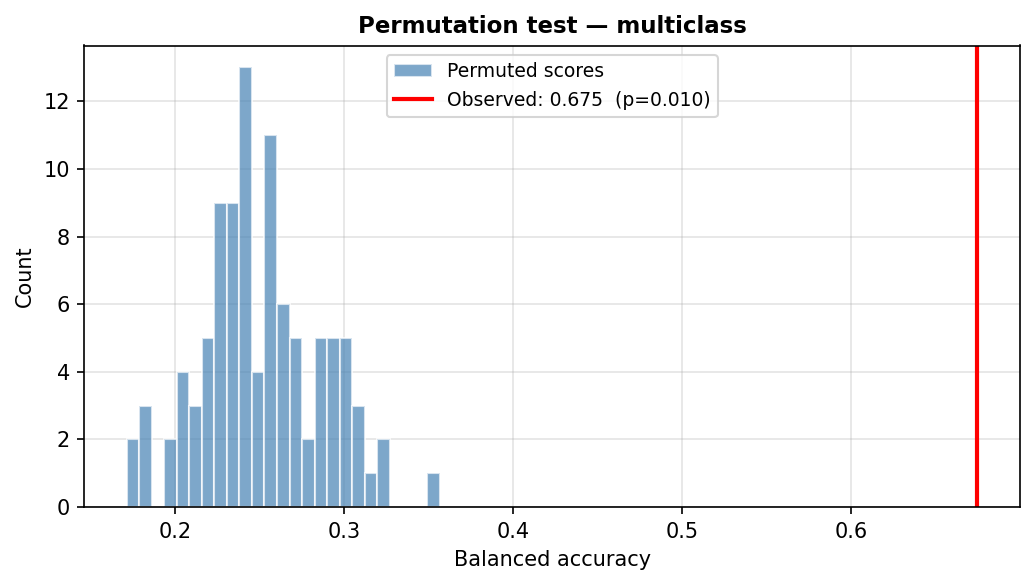

Multiclass permutation test  |  Observed balanced accuracy: 0.675  |  p-value: 0.010


In [10]:
# -------------------------------------------------------------------
# Permutation test (multiclass, balanced accuracy, grouped CV -- see
# grouped_permutation_test docstring above for why this replaces sklearn's
# built-in groups-aware shuffle)
# -------------------------------------------------------------------
score_mc, perm_scores_mc, pval_mc = grouped_permutation_test(
    pipe_mc, X, y_mc, seq_groups, cv_mc, scoring="balanced_accuracy",
    n_permutations=100, random_state=42,
)

fig_pm, ax_pm = plt.subplots(figsize=(7, 4), dpi=150)
ax_pm.hist(perm_scores_mc, bins=25, color="steelblue", alpha=0.7, edgecolor="white",
           label="Permuted scores")
ax_pm.axvline(score_mc, color="red", lw=2,
              label=f"Observed: {score_mc:.3f}  (p={pval_mc:.3f})")
ax_pm.set_xlabel("Balanced accuracy", fontsize=10)
ax_pm.set_ylabel("Count", fontsize=10)
ax_pm.set_title("Permutation test — multiclass", fontsize=11, fontweight="bold")
ax_pm.legend(fontsize=9)
ax_pm.grid(True, alpha=0.35)
ax_pm.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Multiclass permutation test  |  Observed balanced accuracy: {score_mc:.3f}  |  p-value: {pval_mc:.3f}")


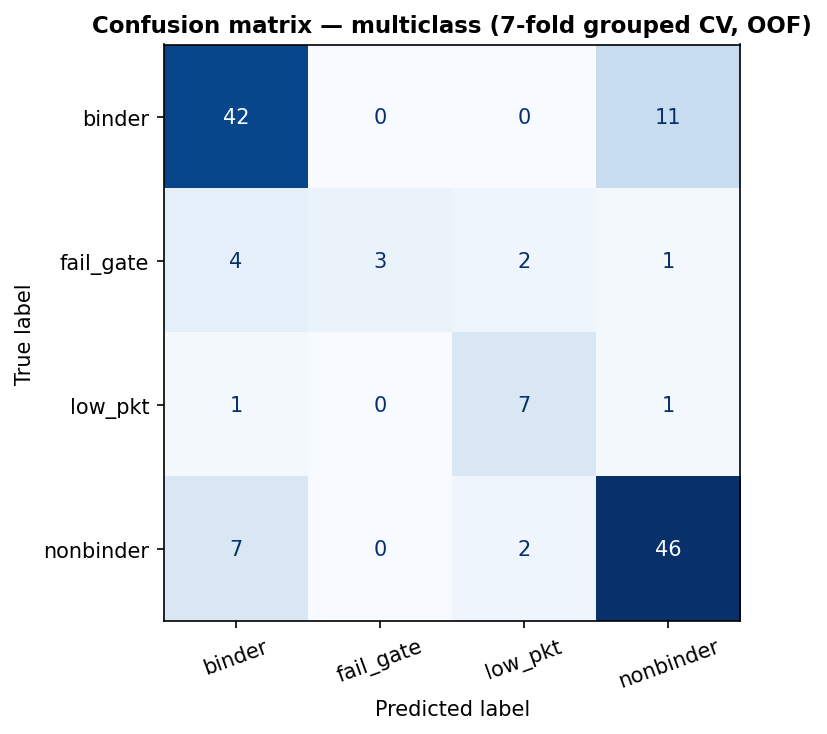

--- Classification report (multiclass, OOF) ---
              precision    recall  f1-score   support

      binder       0.78      0.79      0.79        53
   fail_gate       1.00      0.30      0.46        10
     low_pkt       0.64      0.78      0.70         9
   nonbinder       0.78      0.84      0.81        55

    accuracy                           0.77       127
   macro avg       0.80      0.68      0.69       127
weighted avg       0.79      0.77      0.76       127



In [11]:
# -------------------------------------------------------------------
# Confusion matrix (4-class, grouped CV, OOF predictions)
# -------------------------------------------------------------------
y_pred_mc_cv = cross_val_predict(pipe_mc, X, y_mc, cv=cv_mc, groups=seq_groups)

fig_cm, ax_cm = plt.subplots(figsize=(6, 5), dpi=150)
cm_mc = confusion_matrix(y_mc, y_pred_mc_cv)
disp_mc = ConfusionMatrixDisplay(cm_mc, display_labels=class_names)
disp_mc.plot(ax=ax_cm, colorbar=False, cmap="Blues",
             xticks_rotation=20)
ax_cm.set_title(f"Confusion matrix — multiclass ({N_SPLITS}-fold grouped CV, OOF)",
                fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_cm.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_confusion_matrix_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")

print("--- Classification report (multiclass, OOF) ---")
print(classification_report(y_mc, y_pred_mc_cv, target_names=class_names, zero_division=0))


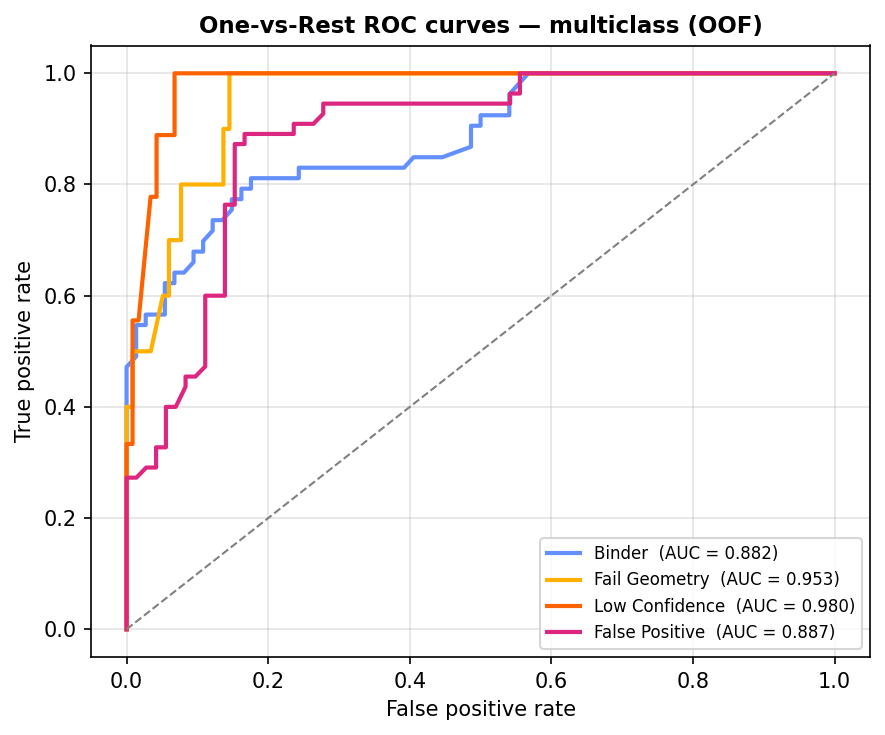

In [12]:
# -------------------------------------------------------------------
# One-vs-Rest ROC curves per class (grouped CV)
# -------------------------------------------------------------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# OOF probability estimates for each class
y_prob_mc_cv = cross_val_predict(pipe_mc, X, y_mc, cv=cv_mc, groups=seq_groups, method="predict_proba")

# Binarize true labels for OvR evaluation
y_mc_bin = label_binarize(y_mc, classes=np.arange(len(class_names)))

# class_names from LabelEncoder are lowercase (binder/fail_gate/low_pkt/nonbinder);
# map to the CLAUDE.md display labels so the IBM colorblind-safe palette below
# actually matches (previously this lookup silently missed every class and fell
# back to matplotlib's default color cycle instead of the project palette).
DISPLAY_LABEL = {
    "binder":    "Binder",
    "nonbinder": "False Positive",
    "low_pkt":   "Low Confidence",
    "fail_gate": "Fail Geometry",
}
palette = {
    'Binder':         '#648FFF',   # blue
    'False Positive': '#DC267F',   # magenta
    'Low Confidence': '#FE6100',   # orange
    'Fail Geometry':  '#FFB000',   # gold
}

fig_roc, ax_roc = plt.subplots(figsize=(6, 5), dpi=150)

for i, cls in enumerate(class_names):
    fpr_i, tpr_i, _ = roc_curve(y_mc_bin[:, i], y_prob_mc_cv[:, i])
    roc_auc_i = auc(fpr_i, tpr_i)
    color = palette.get(DISPLAY_LABEL.get(cls, cls), None)
    ax_roc.plot(fpr_i, tpr_i, lw=2, color=color,
                label=f"{DISPLAY_LABEL.get(cls, cls)}  (AUC = {roc_auc_i:.3f})")

ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax_roc.set_xlabel("False positive rate", fontsize=10)
ax_roc.set_ylabel("True positive rate", fontsize=10)
ax_roc.set_title("One-vs-Rest ROC curves — multiclass (OOF)",
                 fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=8, loc="lower right")
ax_roc.grid(True, alpha=0.35)
ax_roc.set_axisbelow(True)
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_roc.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_ROC-AUC_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")


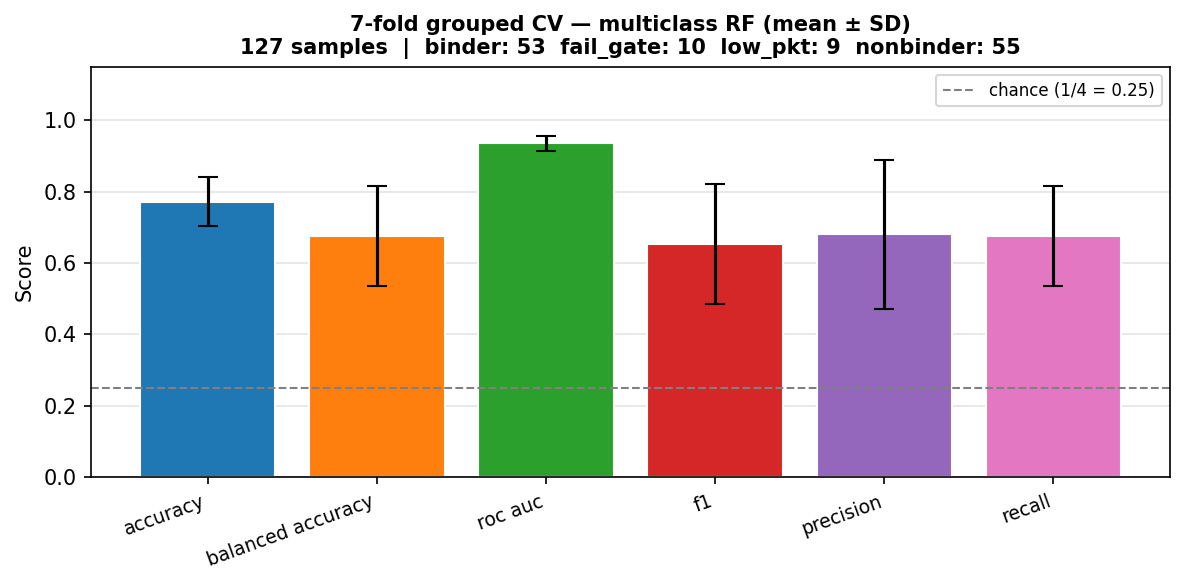

In [13]:
# -------------------------------------------------------------------
# CV metric bar chart — multiclass (matches binary metric set)
# -------------------------------------------------------------------
fig_mc_bar, ax_mc_bar = plt.subplots(figsize=(8, 4), dpi=150)

# Use same display order as binary model
metric_order = ["accuracy", "balanced_accuracy", "roc_auc", "f1", "precision", "recall"]
mc_metric_names = [m for m in metric_order if m in metrics_mc]

mc_means = [metrics_mc[m].mean() for m in mc_metric_names]
mc_sds   = [metrics_mc[m].std()  for m in mc_metric_names]
x_mc     = np.arange(len(mc_metric_names))

ax_mc_bar.bar(x_mc, mc_means, yerr=mc_sds, capsize=5,
              color=plt.get_cmap("tab10")(np.linspace(0, 0.6, len(mc_metric_names))),
              edgecolor="white")
ax_mc_bar.set_xticks(x_mc)
ax_mc_bar.set_xticklabels(
    [m.replace("_", " ") for m in mc_metric_names], rotation=20, ha="right", fontsize=9)
ax_mc_bar.set_ylabel("Score", fontsize=10)
ax_mc_bar.set_ylim(0, 1.15)
n_classes = len(class_names)
ax_mc_bar.axhline(1/n_classes, color="gray", linestyle="--", lw=1,
                  label=f"chance (1/{n_classes} = {1/n_classes:.2f})")

# Part A.5: class counts computed directly from y_mc/class_names rather than
# a hardcoded string, which had drifted out of sync with the actual data
# (previously read "binder: 37 low_confidence: 9 fail_geometry: 10
# false_positive: 17" while the printed class distribution above showed
# different counts entirely).
class_counts_str = "  ".join(f"{cls}: {(y_mc == i).sum()}" for i, cls in enumerate(class_names))
ax_mc_bar.set_title(
    f"{N_SPLITS}-fold grouped CV — multiclass RF (mean ± SD)\n"
    f"{len(y_mc)} samples  |  {class_counts_str}",
    fontsize=10, fontweight="bold")
ax_mc_bar.legend(fontsize=8)
ax_mc_bar.grid(True, axis="y", alpha=0.35)
ax_mc_bar.set_axisbelow(True)
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_mc_bar.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")